In [10]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\Classification\data\cell_samples.csv")
df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [11]:
import numpy as np
df.replace('?',np.nan,inplace=True)
#convert all columns to numeric
df=df.apply(pd.to_numeric)
#Check missing values
df.isnull().sum()
#Handle missing values
df.dropna(inplace=True)

In [12]:
df=df.drop("ID",axis=1)#ID doesnt help in prediction

In [13]:
#Check Target 
df["Class"].value_counts()

Class
2    444
4    239
Name: count, dtype: int64

In [14]:
#Convert values into 0 and 1
df["Class"]=df["Class"].map({2:0,4:1})

In [15]:
#Separate features and target
X=df.drop("Class",axis=1)
y=df['Class']

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
#Scale Data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [19]:
#Train linear SVM
from sklearn.svm import SVC
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
#Predict and Evaluate
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y_pred=svm_linear.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy :  0.9708029197080292
[[78  1]
 [ 3 55]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        79
           1       0.98      0.95      0.96        58

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137



In [22]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train,y_train)
y_pred_rbf=svm_rbf.predict(X_test)
print("RBF Accuracy : ",accuracy_score(y_test,y_pred_rbf))

RBF Accuracy :  0.9635036496350365


In [23]:
#linear SVM is better so lets tune c
for c in [0.1, 1, 10, 100]:
    svm = SVC(kernel='linear', C=c)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    print(f"C={c}, Accuracy={accuracy_score(y_test, y_pred)}")

C=0.1, Accuracy=0.9708029197080292
C=1, Accuracy=0.9708029197080292
C=10, Accuracy=0.9635036496350365
C=100, Accuracy=0.9635036496350365


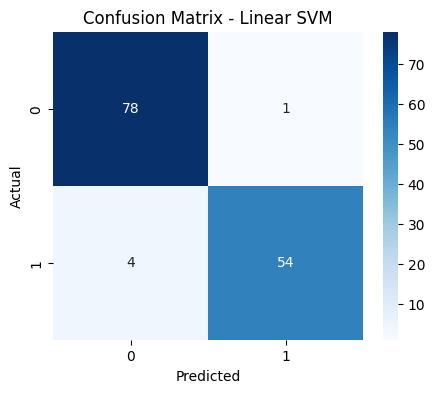

In [24]:
#Confusion Matrix Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [25]:
#ROC curve
svm_linear = SVC(kernel='linear',C=1,probability=True)
svm_linear.fit(X_train,y_train)
y_prob=svm_linear.predict_proba(X_test)[:,1]


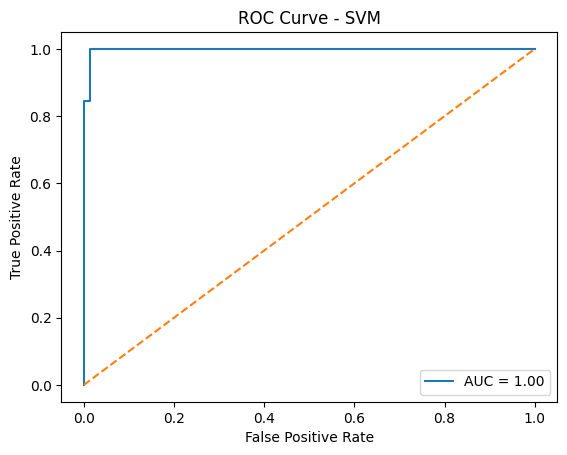

In [26]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

ROC=Receiver Operating Characteristics
It shows : 
X-axis=False Positive Rate: it means out of healthy patients , how many we wrongly flagged.
y-axis=True Positive Rate: it means out of actual cancer cases,how many we detected.
High TPR=good detection.
Very Low FPR=Few false alarms.
AUC=Area under curve.

